# Naive Bayes — Complete Mathematical & Practical Guide

**Learning path:** Problem → Intuition → Probability → Mathematics → From Scratch → Scikit-learn → Evaluation → Tuning → Failure Cases → Applications

This notebook presents Naive Bayes from probability foundations to practical machine-learning workflows.

### Learning objectives
- Understand Bayes' theorem and conditional probability.
- Understand the conditional-independence assumption.
- Derive Gaussian Naive Bayes.
- Implement GaussianNB from scratch.
- Use GaussianNB, MultinomialNB, and BernoulliNB with scikit-learn.
- Evaluate models with classification metrics.
- Apply cross-validation and hyperparameter tuning.
- Understand thresholds, calibration, limitations, and common failure modes.


## 1. Imports and setup

We use NumPy, pandas, Matplotlib, and scikit-learn throughout the notebook.

In [1]:
# Import numerical computing tools.
import numpy as np

# Import pandas for tabular data.
import pandas as pd

# Import Matplotlib for visualization.
import matplotlib.pyplot as plt

# Use a fixed seed for reproducible examples.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Bayes' Theorem

Bayes' theorem describes how we update the probability of a hypothesis after observing new evidence.

### Bayes' Theorem

$$
P(y \mid \mathbf{x})
=
\frac{P(\mathbf{x} \mid y)P(y)}
{P(\mathbf{x})}
$$

Where:

- $P(y)$ is the **prior probability** of the class.
- $P(\mathbf{x} \mid y)$ is the **likelihood** of observing the features given the class.
- $P(\mathbf{x})$ is the **evidence** or marginal probability of the observed features.
- $P(y \mid \mathbf{x})$ is the **posterior probability** of the class given the observed features.

For classification, $P(\mathbf{x})$ is the same for all candidate classes. Therefore, it can be omitted when comparing classes:

$$
\hat{y}
=
\arg\max_y
P(\mathbf{x} \mid y)P(y)
$$

This equation is the fundamental decision rule behind the Naive Bayes classifier.

In [2]:
# Define prior probabilities for two classes.
prior_spam = 0.40
prior_ham = 0.60

# Define the likelihood of observing a particular word.
likelihood_spam = 0.75
likelihood_ham = 0.10

# Calculate unnormalized posterior scores.
score_spam = prior_spam * likelihood_spam
score_ham = prior_ham * likelihood_ham

# Normalize the scores.
evidence = score_spam + score_ham

print(f"P(spam | word) = {score_spam / evidence:.3f}")
print(f"P(ham  | word) = {score_ham / evidence:.3f}")


P(spam | word) = 0.833
P(ham  | word) = 0.167


## 3. The Naive Conditional-Independence Assumption

Naive Bayes assumes that features are conditionally independent given the class:

$$
P(x_1, \ldots, x_d \mid y)
=
\prod_{j=1}^{d} P(x_j \mid y)
$$

Therefore:

$$
P(y \mid \mathbf{x})
\propto
P(y)
\prod_{j=1}^{d} P(x_j \mid y)
$$

The assumption is often unrealistic, but the classifier can still be effective because its goal is classification rather than perfect modeling of the real data-generating process.

## 4. Log Probabilities

Multiplying many small probabilities can cause numerical underflow. Logarithms convert multiplication into addition:

$$
\log P(y \mid \mathbf{x})
\doteq
\log P(y)
+
\sum_{j=1}^{d} \log P(x_j \mid y)
$$

This is why Naive Bayes implementations commonly operate in log space.

## 5. Main Naive Bayes variants

| Variant | Typical feature representation | Distribution |
|---|---|---|
| GaussianNB | Continuous numerical features | Gaussian |
| MultinomialNB | Non-negative counts | Multinomial |
| BernoulliNB | Binary features | Bernoulli |
| ComplementNB | Non-negative count features | Complement statistics |

The feature representation should determine the model variant.


## 6. Gaussian Naive Bayes

GaussianNB assumes each feature follows a Gaussian distribution within each class:

$$
P(x_j \mid y=c)
=
\frac{1}{\sqrt{2\pi\sigma_{cj}^{2}}}
\exp\left(
-\frac{(x_j-\mu_{cj})^2}{2\sigma_{cj}^{2}}
\right)
$$

where:

- $\mu_{cj}$ is the class-specific mean.
- $\sigma_{cj}^{2}$ is the class-specific variance.

In [3]:
# Create a two-dimensional synthetic classification dataset.
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=700,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.25,
    random_state=RANDOM_STATE
)

# Split while preserving the class proportions.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)


Training shape: (525, 2)
Test shape: (175, 2)


## 7. Visualizing the synthetic dataset

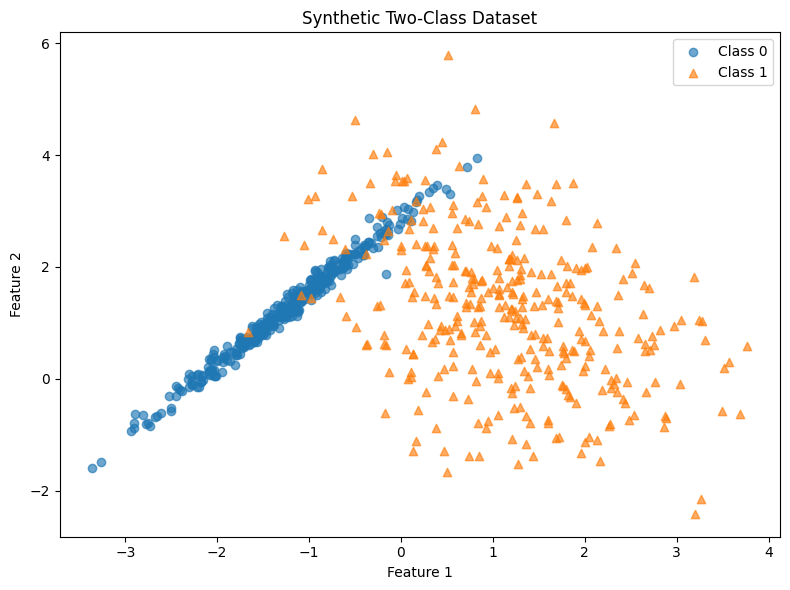

In [4]:
# Plot both classes in the two-dimensional feature space.
plt.figure(figsize=(8, 6))

for class_label, marker in [(0, "o"), (1, "^")]:
    mask = y == class_label

    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        alpha=0.65,
        marker=marker,
        label=f"Class {class_label}"
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Two-Class Dataset")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Gaussian Naive Bayes from scratch

Training estimates:

1. Class priors.
2. Feature means for each class.
3. Feature variances for each class.

Prediction computes a log-posterior score for every class and chooses the largest one.

In [5]:
class GaussianNaiveBayes:
    # A compact educational implementation of Gaussian Naive Bayes.

    def __init__(self, var_smoothing=1e-9):
        # Store the numerical-stability parameter.
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        # Convert inputs to numerical NumPy arrays.
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        # Store unique class labels.
        self.classes_ = np.unique(y)

        # Add a small variance floor.
        epsilon = self.var_smoothing * np.var(X, axis=0).max()

        # Estimate class priors.
        self.class_prior_ = np.array([
            np.mean(y == class_label)
            for class_label in self.classes_
        ])

        # Estimate feature means for each class.
        self.theta_ = np.array([
            X[y == class_label].mean(axis=0)
            for class_label in self.classes_
        ])

        # Estimate feature variances for each class.
        self.var_ = np.array([
            X[y == class_label].var(axis=0) + epsilon
            for class_label in self.classes_
        ])

        return self

    def _joint_log_likelihood(self, X):
        # Convert the input to a numerical array.
        X = np.asarray(X, dtype=float)

        scores = []

        for class_index, _ in enumerate(self.classes_):
            # Calculate the log prior.
            log_prior = np.log(self.class_prior_[class_index])

            # Calculate the Gaussian log-likelihood.
            log_likelihood = -0.5 * np.sum(
                np.log(2 * np.pi * self.var_[class_index])
                + (
                    (X - self.theta_[class_index]) ** 2
                    / self.var_[class_index]
                ),
                axis=1
            )

            # Combine prior and likelihood.
            scores.append(log_prior + log_likelihood)

        return np.column_stack(scores)

    def predict(self, X):
        # Select the class with the largest score.
        scores = self._joint_log_likelihood(X)
        return self.classes_[np.argmax(scores, axis=1)]

    def predict_proba(self, X):
        # Convert log scores into normalized probabilities.
        scores = self._joint_log_likelihood(X)
        scores = scores - scores.max(axis=1, keepdims=True)

        probabilities = np.exp(scores)

        return probabilities / probabilities.sum(axis=1, keepdims=True)


## 9. Training the from-scratch model

In [6]:
# Create and train the educational implementation.
gnb_scratch = GaussianNaiveBayes()
gnb_scratch.fit(X_train, y_train)

# Predict the test set.
y_pred_scratch = gnb_scratch.predict(X_test)

# Display example probabilities.
print("First 10 predictions:")
print(y_pred_scratch[:10])

print("\nFirst 5 probability rows:")
print(gnb_scratch.predict_proba(X_test[:5]))


First 10 predictions:
[0 0 0 1 0 1 1 1 0 1]

First 5 probability rows:
[[5.47478339e-01 4.52521661e-01]
 [9.95609563e-01 4.39043708e-03]
 [9.54963606e-01 4.50363940e-02]
 [5.34865774e-04 9.99465134e-01]
 [9.94416812e-01 5.58318763e-03]]


## 10. GaussianNB with scikit-learn

Scikit-learn provides a tested implementation with the standard estimator interface:

```text
fit → predict → predict_proba
```

This makes the model easy to use with cross-validation and model-selection tools.

In [7]:
# Import GaussianNB and accuracy.
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Train the scikit-learn implementation.
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Generate predictions.
y_pred = gnb.predict(X_test)

# Compare both implementations.
print(f"Scratch accuracy:  {accuracy_score(y_test, y_pred_scratch):.3f}")
print(f"sklearn accuracy: {accuracy_score(y_test, y_pred):.3f}")

# Always inspect class ordering before interpreting probabilities.
print("Class order:", gnb.classes_)


Scratch accuracy:  0.931
sklearn accuracy: 0.931
Class order: [0 1]


## 11. GaussianNB decision regions

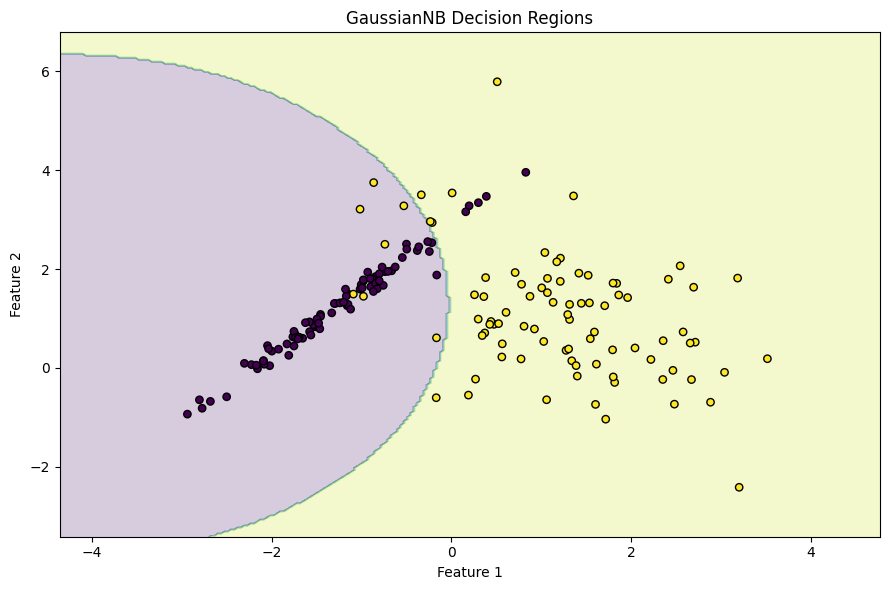

In [8]:
# Build a dense grid covering the feature space.
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250)
)

# Predict every point in the grid.
grid = np.c_[xx.ravel(), yy.ravel()]
Z = gnb.predict(grid).reshape(xx.shape)

# Plot the decision regions and test observations.
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.22)
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    edgecolor="k",
    s=28
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("GaussianNB Decision Regions")
plt.tight_layout()
plt.show()


## 12. Multinomial Naive Bayes

MultinomialNB is commonly used for non-negative count features, such as word counts.

With additive smoothing:

$$
\hat{P}(x_j \mid c)
=
\frac{N_{cj}+\alpha}
{\sum_k N_{ck}+\alpha V}
$$

Smoothing prevents a previously unseen feature from forcing the class likelihood to zero.

In [9]:
# Create a small educational text dataset.
texts = [
    "win money now",
    "claim your prize",
    "limited offer win",
    "cheap loans available",
    "meeting schedule attached",
    "project update tomorrow",
    "please review the report",
    "team meeting at noon",
    "your invoice is attached",
    "exclusive prize claim now",
    "budget review meeting",
    "project deadline reminder"
]

# Label 1 as spam and 0 as non-spam.
labels = np.array([
    1, 1, 1, 1,
    0, 0, 0, 0,
    0, 1, 0, 0
])

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# Put vectorization and classification into one pipeline.
text_model = make_pipeline(
    CountVectorizer(),
    MultinomialNB(alpha=1.0)
)

# Train the text classifier.
text_model.fit(texts, labels)

# Classify new messages.
examples = [
    "claim your exclusive prize",
    "meeting about the project report"
]

print("Predictions:")
print(text_model.predict(examples))

print("\nProbabilities:")
print(text_model.predict_proba(examples))


Predictions:
[1 0]

Probabilities:
[[0.0393441  0.9606559 ]
 [0.97251654 0.02748346]]


## 13. Bernoulli Naive Bayes

BernoulliNB models binary features.

For example:

- `1` → feature is present
- `0` → feature is absent

This differs from MultinomialNB, where a feature can represent a count.

In [10]:
# Import BernoulliNB.
from sklearn.naive_bayes import BernoulliNB

# Create binary features.
X_binary = np.array([
    [1, 1, 0, 0],
    [1, 0, 1, 0],
    [1, 1, 1, 0],
    [0, 0, 1, 1],
    [0, 0, 0, 1],
    [0, 1, 0, 1]
])

y_binary = np.array([1, 1, 1, 0, 0, 0])

# Train the model.
bernoulli_model = BernoulliNB(alpha=1.0)
bernoulli_model.fit(X_binary, y_binary)

print("Predictions:")
print(bernoulli_model.predict(X_binary))

print("\nProbabilities:")
print(bernoulli_model.predict_proba(X_binary))


Predictions:
[1 1 1 0 0 0]

Probabilities:
[[0.05882353 0.94117647]
 [0.05882353 0.94117647]
 [0.02702703 0.97297297]
 [0.94117647 0.05882353]
 [0.97297297 0.02702703]
 [0.94117647 0.05882353]]


## 14. Classification metrics

Important metrics include:

\[
Precision = \frac{TP}{TP+FP}
\]

\[
Recall = \frac{TP}{TP+FN}
\]

\[
F1 = 2\frac{Precision\cdot Recall}{Precision+Recall}
\]

Accuracy alone can be misleading when classes are imbalanced.

In [11]:
# Import classification metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Obtain positive-class probabilities.
y_score = gnb.predict_proba(X_test)[:, 1]

# Calculate several evaluation metrics.
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred, zero_division=0):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_score):.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy:  0.931
Precision: 0.942
Recall:    0.920
F1-score:  0.931
ROC-AUC:   0.970

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        87
           1       0.94      0.92      0.93        88

    accuracy                           0.93       175
   macro avg       0.93      0.93      0.93       175
weighted avg       0.93      0.93      0.93       175



## 15. Confusion matrix

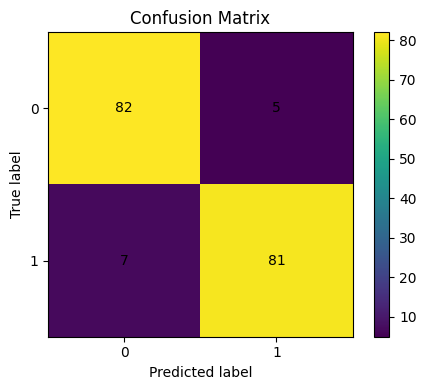

In [12]:
# Calculate the confusion matrix.
cm = confusion_matrix(y_test, y_pred)

# Display the matrix.
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(cm)

ax.set(
    xticks=np.arange(2),
    yticks=np.arange(2),
    xticklabels=gnb.classes_,
    yticklabels=gnb.classes_,
    xlabel="Predicted label",
    ylabel="True label",
    title="Confusion Matrix"
)

# Add counts to the cells.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()


## 16. ROC and Precision-Recall curves

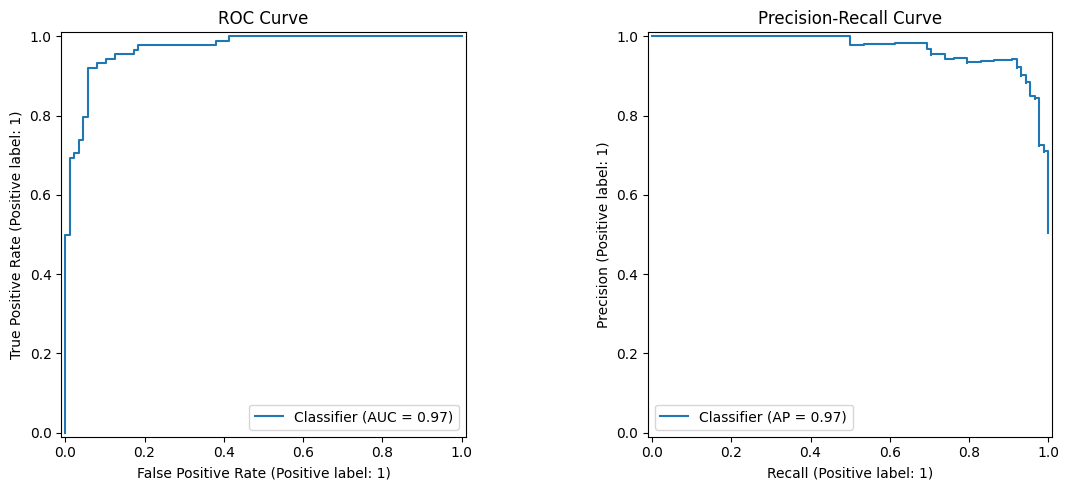

In [13]:
# Import curve display utilities.
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# Create two diagnostic plots.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_score,
    ax=axes[0]
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_score,
    ax=axes[1]
)

axes[0].set_title("ROC Curve")
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


## 17. Decision thresholds

The default threshold is commonly 0.5, but it is not universally optimal.

Changing the threshold changes the balance between false positives and false negatives.

Threshold selection should be performed using validation data, not the final test set.

In [14]:
# Compare several probability thresholds.
for threshold in [0.30, 0.50, 0.70]:
    threshold_pred = (y_score >= threshold).astype(int)

    precision = precision_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    print(
        f"Threshold={threshold:.2f} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )


Threshold=0.30 | Precision=0.892 | Recall=0.943 | F1=0.917
Threshold=0.50 | Precision=0.942 | Recall=0.920 | F1=0.931
Threshold=0.70 | Precision=0.939 | Recall=0.875 | F1=0.906


## 18. Cross-validation and hyperparameter tuning

For GaussianNB, `var_smoothing` controls a small variance-stabilization term.

We use stratified cross-validation and optimize ROC-AUC on the training set. The test set remains untouched until the final evaluation.

In [15]:
# Import cross-validation and grid search.
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Create reproducible stratified folds.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Define candidate values.
param_grid = {
    "var_smoothing": np.logspace(-12, -6, 7)
}

# Build the grid search.
search = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

# Fit only on the training data.
search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print(f"Best mean CV ROC-AUC: {search.best_score_:.3f}")

# Evaluate the selected model on the untouched test set.
test_probability = search.predict_proba(X_test)[:, 1]

print(
    f"Test ROC-AUC: "
    f"{roc_auc_score(y_test, test_probability):.3f}"
)


Best parameters: {'var_smoothing': np.float64(1e-12)}
Best mean CV ROC-AUC: 0.979
Test ROC-AUC: 0.970


## 19. Hyperparameter search visualization

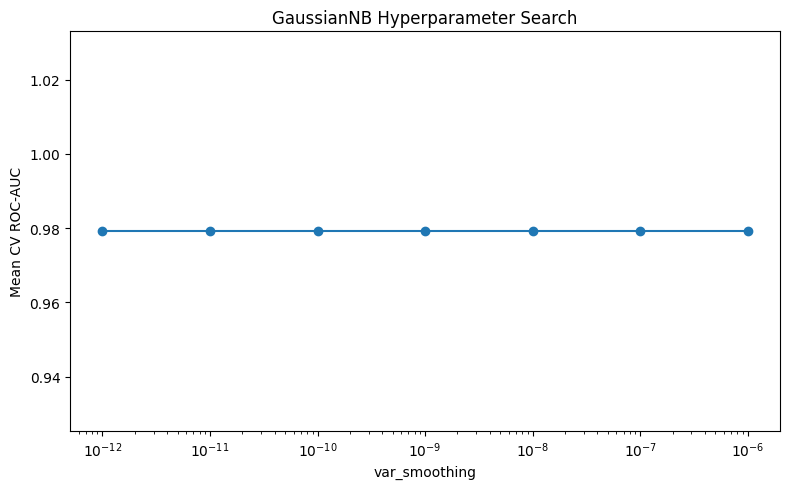

In [16]:
# Convert search results into a DataFrame.
results = pd.DataFrame(search.cv_results_)

# Sort by the tested hyperparameter.
results = results.sort_values("param_var_smoothing")

# Plot mean cross-validation performance.
plt.figure(figsize=(8, 5))

plt.semilogx(
    results["param_var_smoothing"].astype(float),
    results["mean_test_score"],
    marker="o"
)

plt.xlabel("var_smoothing")
plt.ylabel("Mean CV ROC-AUC")
plt.title("GaussianNB Hyperparameter Search")

plt.tight_layout()
plt.show()


## 20. Breast Cancer Wisconsin Dataset

We now use scikit-learn's built-in Breast Cancer Wisconsin dataset.

This dataset is useful for learning classification workflows. Its benchmark performance should not be interpreted as clinical validation.

In [17]:
# Load the built-in Breast Cancer Wisconsin dataset.
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)

X_cancer = cancer.data
y_cancer = cancer.target

print("Feature matrix shape:", X_cancer.shape)
print("Target names:", cancer.target_names)

print("\nClass counts:")
print(y_cancer.value_counts().sort_index())

display(X_cancer.head())


Feature matrix shape: (569, 30)
Target names: ['malignant' 'benign']

Class counts:
target
0    212
1    357
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 21. Training GaussianNB on the medical dataset

In [18]:
# Create a stratified train/test split.
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.25,
    stratify=y_cancer,
    random_state=RANDOM_STATE
)

# Train GaussianNB.
cancer_nb = GaussianNB()
cancer_nb.fit(Xc_train, yc_train)

# Generate predictions and probabilities.
yc_pred = cancer_nb.predict(Xc_test)
yc_prob = cancer_nb.predict_proba(Xc_test)[:, 1]

print("Class order:", cancer_nb.classes_)
print(f"Accuracy:  {accuracy_score(yc_test, yc_pred):.3f}")
print(f"Precision: {precision_score(yc_test, yc_pred):.3f}")
print(f"Recall:    {recall_score(yc_test, yc_pred):.3f}")
print(f"F1-score:  {f1_score(yc_test, yc_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(yc_test, yc_prob):.3f}")


Class order: [0 1]
Accuracy:  0.937
Precision: 0.926
Recall:    0.978
F1-score:  0.951
ROC-AUC:   0.989


## 22. Probability calibration

A model can rank observations well while producing poorly calibrated probabilities.

For example, a well-calibrated model should have approximately 80% positive outcomes among a large representative group receiving predicted probabilities around 0.8.

Calibration should be assessed separately from discrimination metrics such as ROC-AUC.

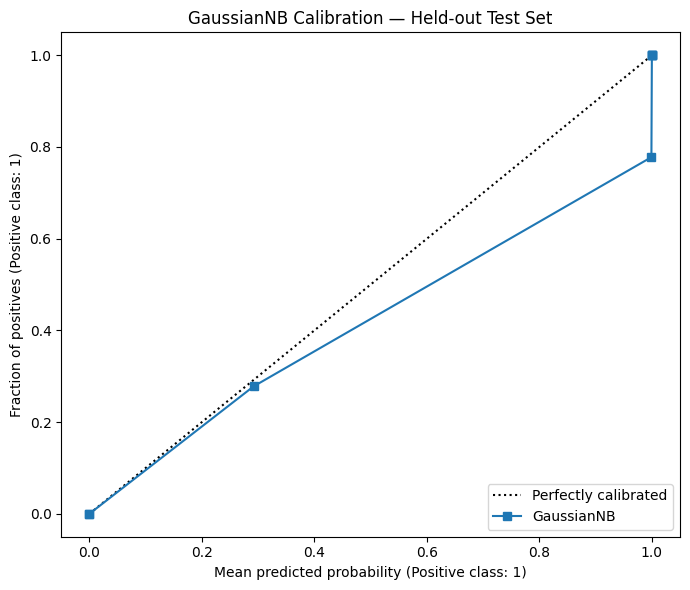

In [19]:
# Import the calibration visualization.
from sklearn.calibration import CalibrationDisplay

# Create a reliability diagram on held-out data.
fig, ax = plt.subplots(figsize=(7, 6))

CalibrationDisplay.from_estimator(
    cancer_nb,
    Xc_test,
    yc_test,
    n_bins=8,
    strategy="quantile",
    ax=ax
)

ax.set_title("GaussianNB Calibration — Held-out Test Set")

plt.tight_layout()
plt.show()


## 23. Class priors and class imbalance

Naive Bayes estimates:
$$
P(y)
$$
from the training data by default.

If the deployment population has a different class prevalence, posterior probabilities may shift.

Always inspect:

- class distribution,
- target prevalence,
- deployment population,
- false-positive and false-negative costs.

In [20]:
# Inspect learned class priors.
print("Learned class priors:")
print(cancer_nb.class_prior_)

# Compare with observed training proportions.
print("\nObserved training proportions:")
print(
    yc_train.value_counts(normalize=True)
    .sort_index()
    .to_dict()
)


Learned class priors:
[0.37323944 0.62676056]

Observed training proportions:
{0: 0.3732394366197183, 1: 0.6267605633802817}


## 24. Feature dependence and limitations

The conditional-independence assumption can be violated when features are correlated.

Other limitations include:

- GaussianNB assumes Gaussian class-conditional distributions.
- MultinomialNB expects non-negative count-like features.
- BernoulliNB models binary events.
- Probability estimates may be poorly calibrated.
- Distribution shift can degrade performance.
- Correlated features may cause redundant evidence to be counted multiple times.

Naive Bayes remains useful as a fast and interpretable probabilistic baseline.

## 25. Feature scaling

Unlike KNN and many SVM workflows, GaussianNB generally does not require standardization for its basic probability model because it estimates a separate mean and variance for every feature.

However, preprocessing still must be leakage-safe.

For count-based models, preprocessing must also preserve the assumptions of the selected distribution.

## 26. Naive Bayes vs Logistic Regression vs SVM

| Property | Naive Bayes | Logistic Regression | SVM |
|---|---|---|---|
| Main idea | Generative probability model | Discriminative probability model | Maximum-margin classifier |
| Typical strength | Fast baseline and text classification | Strong linear baseline | Margin-based and kernel classification |
| Probability output | Native; calibration may be imperfect | Probability model | Optional with `SVC` |
| Scaling | Variant-dependent | Often useful | Usually important |

There is no universally best classifier. Models should be compared using identical data splits, preprocessing, validation, and metrics.

## 27. Common mistakes

1. Choosing the wrong Naive Bayes variant.
2. Passing negative features to MultinomialNB.
3. Ignoring `model.classes_` when interpreting probabilities.
4. Tuning hyperparameters on the test set.
5. Treating model probabilities as guaranteed calibrated risks.
6. Reporting accuracy without inspecting class-specific errors.
7. Performing preprocessing before cross-validation and causing leakage.

## 28. Practical workflow

```text
Define the problem
        ↓
Inspect feature representation
        ↓
Choose Naive Bayes variant
        ↓
Split data
        ↓
Train baseline
        ↓
Cross-validation
        ↓
Hyperparameter tuning
        ↓
Threshold / calibration analysis
        ↓
Final test evaluation
        ↓
Error analysis
        ↓
Document limitations
```


## 29. Applications in Bioinformatics and Medical AI

Naive Bayes can serve as a baseline for:

- Gene-expression classification
- Disease subtype classification
- Biomarker classification
- Biomedical text classification
- Clinical feature classification
- Molecular and genomic feature analysis

For medical AI, performance should be assessed with patient-level splitting, leakage checks, external validation when possible, calibration, subgroup analysis, and distribution-shift analysis.

## 30. Exercises

1. Change `alpha` in MultinomialNB and observe the effect.
2. Compare GaussianNB, Logistic Regression, and SVM with the same cross-validation folds.
3. Add correlated features and inspect the effect on Naive Bayes.
4. Plot precision and recall for different thresholds.
5. Compare `CountVectorizer` and `TfidfVectorizer` with MultinomialNB.
6. Investigate calibration with a leakage-safe validation strategy.
7. Build a complete Naive Bayes pipeline on a biomedical classification dataset.

## 31. Final Summary

The core ideas are:

1. Bayes' theorem combines priors and likelihoods.
2. Naive Bayes assumes conditional independence between features given the class.
3. GaussianNB models continuous features with class-specific Gaussian distributions.
4. MultinomialNB is useful for non-negative count features.
5. BernoulliNB models binary feature presence/absence.
6. Log probabilities improve numerical stability.
7. Smoothing prevents zero-probability problems.
8. Accuracy should not be the only evaluation metric.
9. Cross-validation belongs inside model selection.
10. The final test set should remain isolated until the final evaluation.

## References

- [Scikit-learn — Naive Bayes User Guide](https://scikit-learn.org/stable/modules/naive_bayes.html)
- [Scikit-learn — GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html)
- [Scikit-learn — MultinomialNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html)
- [Scikit-learn — BernoulliNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html)
- [Scikit-learn — Breast Cancer Wisconsin Dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)
